# Fourier Power Spectrum and Spectral Filtering

---

## Overview

The **Fourier transform** decomposes a time series into sine and cosine waves at different frequencies. The **power spectrum** shows how much variance each frequency explains, useful for spotting the annual cycle, intraseasonal variability, and other climate signals.

In this notebook we:

1. Load daily OLR at a single grid point.
2. Compute and interpret the **power spectrum** of that pixel time series.
3. Apply **low-pass, high-pass, and band-pass** filters in frequency space.

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Remove the seasonal cycle using harmonic regression](./02.harmonic_anomalies.ipynb) | Helpful | Same OLR dataset and pixel-selection workflow |
| Discrete Fourier transform | Necessary | Amplitude, frequency, and period |

- **Time to learn**: ~25 minutes

---

## Imports

All packages are imported up front. `s3fs` reads anonymously from the public Pythia bucket on the Jetstream2 S3 endpoint.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import s3fs
import xarray as xr

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)

URL = "https://js2.jetstream-cloud.org:8001/"
fs = s3fs.S3FileSystem(anon=True, client_kwargs=dict(endpoint_url=URL))

## Load NOAA OLR

We use daily **Outgoing Longwave Radiation (OLR)** from NOAA, stored as a Zarr dataset on the Pythia Jetstream2 bucket, the same source as in [harmonic anomalies](./harmonic_anomalies.ipynb).

In [10]:
olr_noaa_store = s3fs.S3Map(
    root="pythia/olr_noaa.zarr",
    s3=fs,
    check=False,
)

olr_noaa = xr.open_zarr(olr_noaa_store)
olr_noaa = olr_noaa.rename_vars({"__xarray_dataarray_variable__": "olr"})
olr_noaa = olr_noaa.chunk({"time": -1})
olr_noaa = olr_noaa.interpolate_na(dim="time", method="linear")

## Select a single-pixel time series

Spectral analysis starts with one location. We pick a tropical grid point and remove the time mean so the FFT focuses on variability rather than the absolute OLR level.

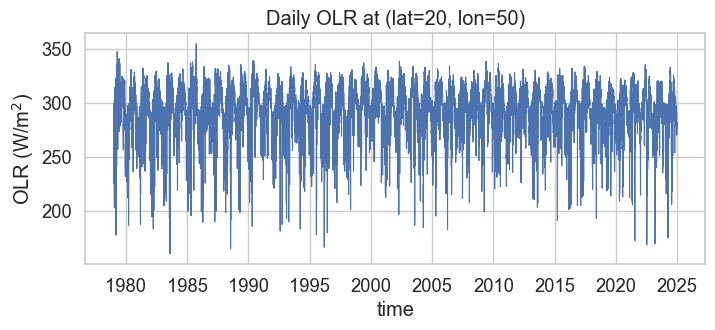

In [11]:
lat_select = 20
lon_select = 50

olr_series = olr_noaa["olr"].sel(
    lat=lat_select, lon=lon_select, method="nearest"
)
series = olr_series.values
series_centered = series - series.mean()
n_time = len(series)

fig, ax = plt.subplots(figsize=(8, 3))
olr_series.plot(ax=ax, color="C0", linewidth=0.8)
ax.set_title(f"Daily OLR at (lat={lat_select}, lon={lon_select})")
ax.set_ylabel("OLR (W/m$^2$)")
plt.show()

## Compute the power spectrum

For a centered series $x(t)$ with sampling interval $\Delta t = 1$ day, the discrete Fourier transform gives complex coefficients $\hat{x}_k$. The **power** at frequency $k$ is $|\hat{x}_k|^2$. Summing power across all frequencies equals the series variance.

We convert frequency to **period** (days) with $\text{period} = 1 / |f|$ and express each bin as the **fraction of total variance** it explains. Peaks near 365 days mark the annual cycle and its harmonics.

In [12]:
def power_spectrum(series, dt=1.0):
    """Return positive-frequency periods (days) and explained variance (%)."""
    x = series - np.mean(series)
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=dt)
    coeffs = np.fft.rfft(x)
    power = np.abs(coeffs) ** 2

    var = np.var(x)
    pct_var = 100.0 * power / power.sum() if power.sum() > 0 else power

    with np.errstate(divide="ignore"):
        periods = np.where(freqs > 0, 1.0 / freqs, np.inf)

    mask = freqs > 0
    return periods[mask], pct_var[mask], var


periods, pct_var, series_var = power_spectrum(series)
print(f"Series length: {n_time} days | variance: {series_var:.2f} (W/m$^2$)$^2$")

Series length: 16802 days | variance: 492.19 (W/m$^2$)$^2$


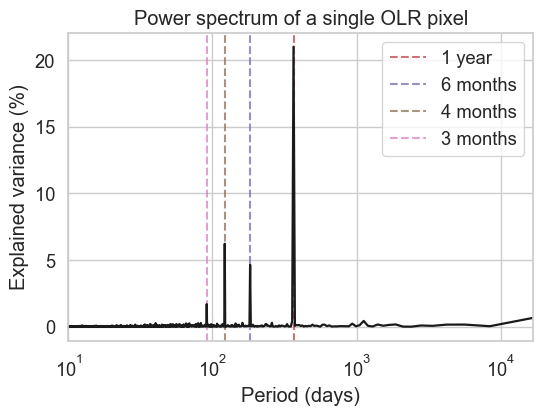

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(periods, pct_var, color="k", linewidth=1.6)
ax.set_xscale("log")
ax.set_xlim(10, n_time)
ax.set_xlabel("Period (days)")
ax.set_ylabel("Explained variance (%)")
ax.set_title("Power spectrum of a single OLR pixel")

for period, label, color in [
    (365.25, "1 year", "C3"),
    (365.25 / 2, "6 months", "C4"),
    (365.25 / 3, "4 months", "C5"),
    (365.25 / 4, "3 months", "C6"),
]:
    ax.axvline(period, color=color, linestyle="--", alpha=0.8, label=label, zorder=1)
ax.legend(loc="upper right")
plt.show()

As we see, the largest peaks usually occur near the **annual cycle** and its harmonics. While this confirms that the seasonal cycle is the dominant source of variability, it offers little new insight, as this behavior is already well known.

To reveal variability beyond the seasonal cycle, we repeat the analysis using anomalies obtained after removing the annual cycle and its first four harmonics, following the procedure described in [Remove the seasonal cycle using harmonic regression](./02.harmonic_anomalies.ipynb). This filtering suppresses the seasonal signal, allowing other modes of variability to emerge more clearly.

In [28]:
n_harmonics = 4
year_period = 365.25  # days

t = np.arange(n_time)
X = np.ones((n_time, 2 * n_harmonics + 1))
for i in range(1, n_harmonics + 1):
    X[:, 2 * i - 1] = np.sin(i * 2 * np.pi * t / year_period)
    X[:, 2 * i] = np.cos(i * 2 * np.pi * t / year_period)


coeffs = np.linalg.lstsq(X, series, rcond=None)[0]
annual_cycle = X @ coeffs
anomalies = series - annual_cycle

periods, pct_var_harmonics, series_var_harmonics = power_spectrum(anomalies)


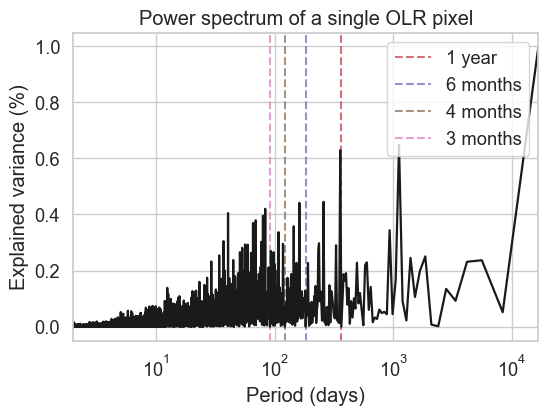

In [43]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(periods, pct_var_harmonics, color="k", linewidth=1.6)
ax.set_xscale("log")
ax.set_xlim(2, n_time)
ax.set_xlabel("Period (days)")
ax.set_ylabel("Explained variance (%)")
ax.set_title("Power spectrum of a single OLR pixel")

for period, label, color in [
    (365.25, "1 year", "C3"),
    (365.25 / 2, "6 months", "C4"),
    (365.25 / 3, "4 months", "C5"),
    (365.25 / 4, "3 months", "C6"),
]:
    ax.axvline(period, color=color, linestyle="--", alpha=0.8, label=label, zorder=1)
ax.legend(loc="upper right")
plt.show()

Now we see that the largest fraction of the explained variability is concentrated at low frequencies, corresponding to periods longer than $10^4$ days. A substantial amount of variance is also found in the interannual band (approximately 2–7 years), while another significant contribution arises from intraseasonal variability, with periods between about 20 and 90 days.

## Spectral filtering

Spectral filtering isolates variability within a desired range of time scales by modifying the Fourier coefficients before transforming the signal back to the time domain. The procedure consists of three steps:

1. Compute the FFT of the mean-centered time series.
2. Retain only the Fourier coefficients corresponding to the desired period range.
3. Perform the inverse FFT and add the mean back to reconstruct the filtered signal.

---

| Filter | Keeps periods | Typical use |
| --- | --- | --- |
| **Low-pass** | longer than a cutoff | isolate slow variability (e.g., interannual to decadal) |
| **High-pass** | shorter than a cutoff | remove slow variations such as trends and the seasonal cycle |
| **Band-pass** | between two cutoffs | isolate a specific range of variability (e.g., MJO) |

The helper function `spectral_filter` below implements this procedure using NumPy. After removing the time mean, it computes the real FFT (`np.fft.rfft`) and converts each frequency bin to its corresponding period, \(T = 1/f\). A boolean mask is then applied to determine which Fourier coefficients are retained.

The filtering options are:

- **Low-pass:** specify `period_min` only, retaining periods $( T \geq T_{\min} )$.
- **High-pass:** specify `period_max` only, retaining periods $(T \leq T_{\max})$.
- **Band-pass:** specify both `period_min` and `period_max`, retaining periods $(T_{\min} \leq T \leq T_{\max})$.

The zero-frequency (DC) component is always removed because the mean has already been subtracted. The filtered time series is then reconstructed with `np.fft.irfft`.

Below, we apply these filters to the harmonic anomalies, using a 100-day cutoff to separate low- and high-frequency variability and a 20–90 day band-pass filter to isolate intraseasonal fluctuations, including signals associated with the Madden–Julian Oscillation (MJO).

In [ ]:
def spectral_filter(series, period_min=None, period_max=None, dt=1.0):
    """Band-pass in period space; omit period_min or period_max for high/low pass."""
    mean = np.mean(series)
    x = series - mean
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=dt)
    coeffs = np.fft.rfft(x)

    with np.errstate(divide="ignore"):
        freq_periods = np.where(freqs > 0, 1.0 / freqs, np.inf)

    keep = np.ones_like(freqs, dtype=bool)
    if period_max is not None:
        keep &= freq_periods <= period_max
    if period_min is not None:
        keep &= freq_periods >= period_min
    keep[0] = False  # remove the DC (mean) component

    coeffs_filtered = np.where(keep, coeffs, 0.0)
    return np.fft.irfft(coeffs_filtered, n=n)


cutoff = 100  # days
bp_low, bp_high = 20, 90  # days

lowpass = spectral_filter(anomalies, period_min=cutoff)
highpass = spectral_filter(anomalies, period_max=cutoff)
bandpass = spectral_filter(anomalies, period_min=bp_low,
                           period_max=bp_high)

Compare the original series with each filtered version over two years. The low-pass trace follows the seasonal envelope; the high-pass trace removes it; the band-pass trace isolates intraseasonal swings.

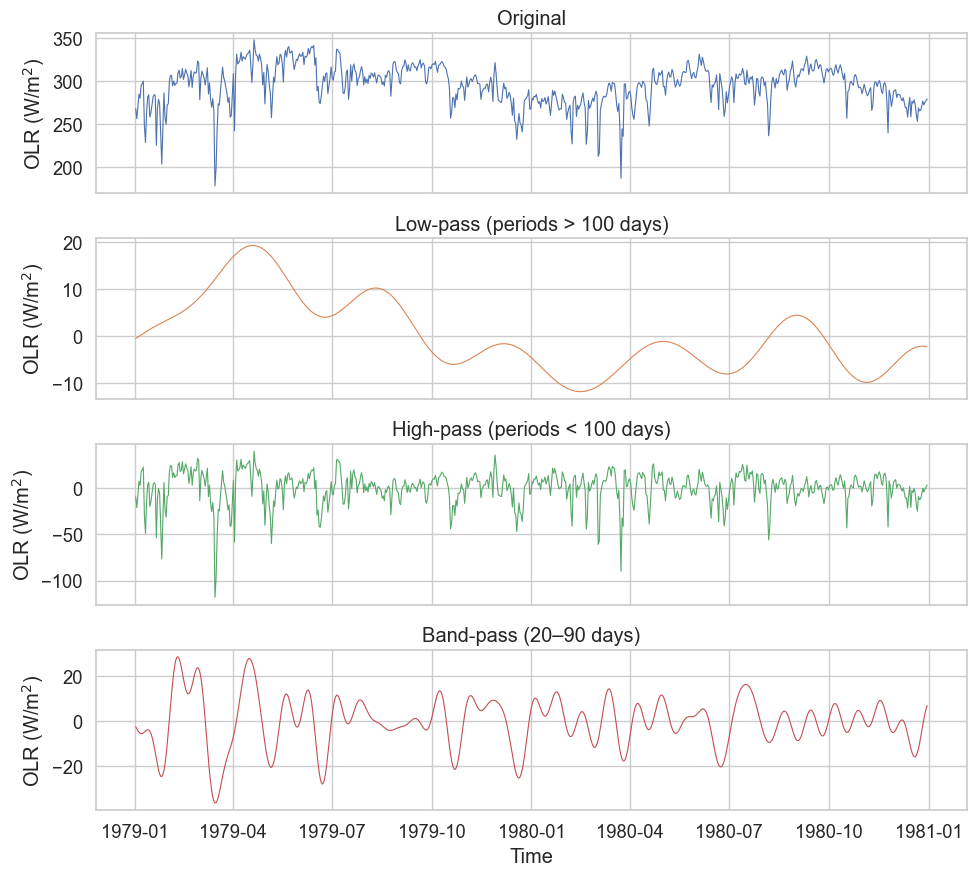

In [30]:
two_years = slice(0, int(365.25 * 2))
time_slice = olr_series.time[two_years]

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
panels = [
    (series[two_years], "Original", "C0"),
    (lowpass[two_years], f"Low-pass (periods > {cutoff} days)", "C1"),
    (highpass[two_years], f"High-pass (periods < {cutoff} days)", "C2"),
    (bandpass[two_years], f"Band-pass ({bp_low}–{bp_high} days)", "C3"),
]
for ax, (data, title, color) in zip(axes, panels):
    ax.plot(time_slice, data, color=color, linewidth=0.8)
    ax.set_ylabel("OLR (W/m$^2$)")
    ax.set_title(title)
axes[-1].set_xlabel("Time")
fig.tight_layout()
plt.show()

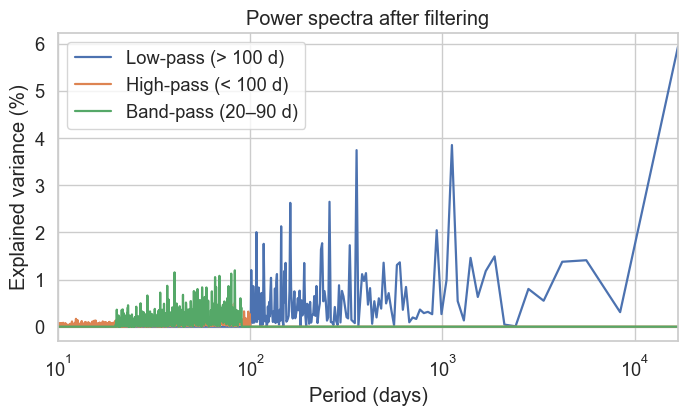

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
for filtered, label in [
    (lowpass, f"Low-pass (> {cutoff} d)"),
    (highpass, f"High-pass (< {cutoff} d)"),
    (bandpass, f"Band-pass ({bp_low}–{bp_high} d)"),
]:
    p, pv, _ = power_spectrum(filtered)
    ax.plot(p, pv, label=label, linewidth=1.6)

ax.set_xscale("log")
ax.set_xlim(10, n_time)
ax.set_xlabel("Period (days)")
ax.set_ylabel("Explained variance (%)")
ax.set_title("Power spectra after filtering")
ax.legend()
plt.show()

---

## Summary

The **power spectrum** of a single-pixel time series reveals which time scales carry the most variance, often the annual cycle at ~365 days. **Spectral filters** multiply the Fourier coefficients by a mask: low-pass keeps slow variations, high-pass keeps fast ones, and band-pass targets a range such as 20–90 days for intraseasonal studies.

### What's next?

TBD